In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [34]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    d: float
    result: str

In [35]:
def show_equation(state: QuadState):
    equation = f'({state["a"]}x2)+({state["b"]}x)+({state["c"]})'

    return {'equation': equation}

def calculate_d(state: QuadState):
    d = state["b"]**2 - (4*state["a"]*state["c"])

    return {'d': d}

def real_roots(state: QuadState):
    r1 = (-state["b"] + state["d"]**0.5)/(2*state["a"])
    r2 = (-state["b"] - state["d"]**0.5)/(2*state["a"])

    result = f'The roots are {r1} and {r2}'
    return {'result': result}

def repeated_roots(state: QuadState):
    r = -state["b"]/(2*state["a"])

    result = f'Only repeating root is {r}'

    return {'result': result}

def no_real_roots(state: QuadState):
    result = f'No real Roots.'

    return {'result': result}

def check_condition(state: QuadState) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state['d'] > 0:
        return "real_roots"
    
    elif state["d"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"


In [36]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_d', calculate_d)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_d')
graph.add_conditional_edges('calculate_d', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

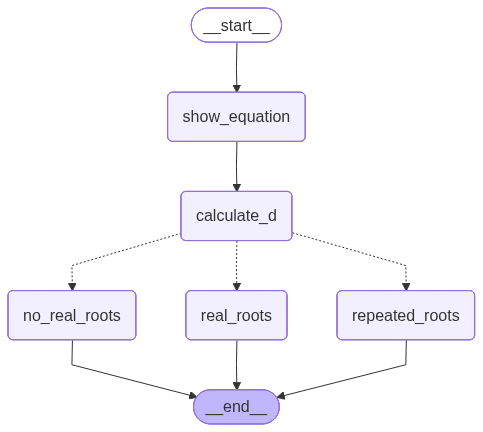

In [37]:
workflow

In [38]:
initial_state = {
    'a' : 4,
    'b': -5,
    'c': 4
}

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': 4,
 'equation': '(4x2)+(-5x)+(4)',
 'd': -39,
 'result': 'No real Roots.'}